In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset (replace with your dataset if needed)
df = pd.read_csv("titanic.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [4]:
# 1. Feature Engineering

# Clean up column names (adjust if your data is different)
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'passengerid': 'passenger_id', 'sibsp': 'siblings_spouses', 'parch': 'parents_children', '2urvived': 'survived'}, inplace=True)

# Drop unnecessary/all-zero columns
zero_cols = [col for col in df.columns if col.startswith('zero')]
df.drop(columns=zero_cols, inplace=True)

In [5]:
# Feature Engineering (at least 10)

# 1. Fare per person
df['fare_per_person'] = df['fare'] / (df['siblings_spouses'] + df['parents_children'] + 1)

# 2. Family size
df['family_size'] = df['siblings_spouses'] + df['parents_children'] + 1

# 3. Is alone
df['is_alone'] = np.where(df['family_size'] == 1, 1, 0)

# 4. Age * Pclass interaction
df['age_pclass'] = df['age'] * df['pclass']


# 5. Fare * Pclass interaction
df['fare_pclass'] = df['fare'] * df['pclass']

# 6. Age squared (polynomial feature)
df['age_squared'] = df['age'] ** 2

# 7. Fare squared
df['fare_squared'] = df['fare'] ** 2


# 8. Fare cubed
df['fare_cubed'] = df['fare']**3

# 9. Fare per person * pclass
df['fare_per_person_pclass'] = df['fare_per_person']*df['pclass']

# 10. Sibling/spouse indicator
df['has_sibsp'] = np.where(df['siblings_spouses'] > 0, 1, 0)

# 11. Parent/child indicator
df['has_parch'] = np.where(df['parents_children'] > 0, 1, 0)

In [6]:
df.head()

,passenger_id,age,fare,sex,siblings_spouses,parents_children,pclass,embarked,survived,fare_per_person,family_size,is_alone,age_pclass,fare_pclass,age_squared,fare_squared,fare_cubed,fare_per_person_pclass,has_sibsp,has_parch
0,1,22.0,7.2500,0,1,0,3,2.0,0,3.62500,2,0,66.0,21.7500,484.0,52.562500,381.078125,10.87500,1,0
1,2,38.0,71.2833,1,1,0,1,0.0,1,35.64165,2,0,38.0,71.2833,1444.0,5081.308859,362212.463781,35.64165,1,0
2,3,26.0,7.9250,1,0,0,3,2.0,1,7.92500,1,1,78.0,23.7750,676.0,62.805625,497.734578,23.77500,0,0
3,4,35.0,53.1000,1,1,0,1,2.0,1,26.55000,2,0,35.0,53.1000,1225.0,2819.610000,149721.291000,26.55000,1,0
4,5,35.0,8.0500,0,0,0,3,2.0,0,8.05000,1,1,105.0,24.1500,1225.0,64.802500,521.660125,24.15000,0,0


In [7]:
# Encode categorical features (sex and embarked)
df['sex'] = df['sex'].astype(int)  # Assuming 0 and 1 encoding already present

embarked_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
embarked_encoded = embarked_encoder.fit_transform(df[['embarked']])
embarked_df = pd.DataFrame(embarked_encoded, columns=embarked_encoder.get_feature_names_out(['embarked']))
df = pd.concat([df, embarked_df], axis=1)
df.drop(columns=['embarked'], inplace=True)

df['age'] = df['age'].fillna(df['age'].median()) # Handle missing ages (simple imputation for this example)
df['fare'] = df['fare'].fillna(df['fare'].median())  # Fill missing fares as well

In [8]:
df.head()

,passenger_id,age,fare,sex,siblings_spouses,parents_children,pclass,survived,fare_per_person,family_size,...,age_squared,fare_squared,fare_cubed,fare_per_person_pclass,has_sibsp,has_parch,embarked_0.0,embarked_1.0,embarked_2.0,embarked_nan
0,1,22.0,7.2500,0,1,0,3,0,3.62500,2,...,484.0,52.562500,381.078125,10.87500,1,0,0.0,0.0,1.0,0.0
1,2,38.0,71.2833,1,1,0,1,1,35.64165,2,...,1444.0,5081.308859,362212.463781,35.64165,1,0,1.0,0.0,0.0,0.0
2,3,26.0,7.9250,1,0,0,3,1,7.92500,1,...,676.0,62.805625,497.734578,23.77500,0,0,0.0,0.0,1.0,0.0
3,4,35.0,53.1000,1,1,0,1,1,26.55000,2,...,1225.0,2819.610000,149721.291000,26.55000,1,0,0.0,0.0,1.0,0.0
4,5,35.0,8.0500,0,0,0,3,0,8.05000,1,...,1225.0,64.802500,521.660125,24.15000,0,0,0.0,0.0,1.0,0.0


In [9]:
# 2. Feature Selection
X = df.drop(columns=['survived', 'passenger_id'])  # Features
y = df['survived']  # Target variable
df.head()

,passenger_id,age,fare,sex,siblings_spouses,parents_children,pclass,survived,fare_per_person,family_size,...,age_squared,fare_squared,fare_cubed,fare_per_person_pclass,has_sibsp,has_parch,embarked_0.0,embarked_1.0,embarked_2.0,embarked_nan
0,1,22.0,7.2500,0,1,0,3,0,3.62500,2,...,484.0,52.562500,381.078125,10.87500,1,0,0.0,0.0,1.0,0.0
1,2,38.0,71.2833,1,1,0,1,1,35.64165,2,...,1444.0,5081.308859,362212.463781,35.64165,1,0,1.0,0.0,0.0,0.0
2,3,26.0,7.9250,1,0,0,3,1,7.92500,1,...,676.0,62.805625,497.734578,23.77500,0,0,0.0,0.0,1.0,0.0
3,4,35.0,53.1000,1,1,0,1,1,26.55000,2,...,1225.0,2819.610000,149721.291000,26.55000,1,0,0.0,0.0,1.0,0.0
4,5,35.0,8.0500,0,0,0,3,0,8.05000,1,...,1225.0,64.802500,521.660125,24.15000,0,0,0.0,0.0,1.0,0.0


In [16]:
# Correlation Matrix
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.8)]
X_corr = X.drop(columns=to_drop_corr)

In [11]:
# Variance Threshold
selector = VarianceThreshold(threshold=0.01)  # Adjust threshold if needed
X_var = selector.fit_transform(X)
X_var = pd.DataFrame(X_var, columns=X.columns[selector.get_support()])

In [12]:
# PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
X_pca = pca.fit_transform(X_scaled)


In [13]:
# Model-Based Selection (RandomForest)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = X.columns[indices][:5] # Top 5 features
X_rf = X[top_features]

In [17]:
# 2.5 Model Comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_corr, X_test_corr, _, _ = train_test_split(X_corr, y, test_size=0.2, random_state=42)
X_train_var, X_test_var, _, _ = train_test_split(X_var, y, test_size=0.2, random_state=42)
X_train_rf, X_test_rf, _, _ = train_test_split(X_rf, y, test_size=0.2, random_state=42)

In [18]:
# Scale data for models that benefit from it
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train_corr = scaler.fit_transform(X_train_corr)
X_test_corr = scaler.transform(X_test_corr)
X_train_var = scaler.fit_transform(X_train_var)
X_test_var = scaler.transform(X_test_var)
X_train_rf = scaler.fit_transform(X_train_rf)
X_test_rf = scaler.transform(X_test_rf)

In [22]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}
results = []

datasets = {
    'Original': (X_train, X_test),
    'Correlation Matrix': (X_train_corr, X_test_corr),
    'Variance Threshold': (X_train_var, X_test_var),
    'Random Forest':(X_train_rf, X_test_rf)
}



for dataset_name, (X_train_data, X_test_data) in datasets.items():
    for model_name, model in models.items():

        model.fit(X_train_data, y_train)
        y_pred = model.predict(X_test_data)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results.append([dataset_name, model_name, accuracy, f1])

results_df = pd.DataFrame(results, columns=['Dataset', 'Model', 'Accuracy', 'F1 Score'])
print("\nModel Comparison Table:\n", results_df)


Model Comparison Table:
               Dataset                Model  Accuracy  F1 Score
0            Original  Logistic Regression  0.778626  0.491228
1            Original        Decision Tree  0.675573  0.465409
2  Correlation Matrix  Logistic Regression  0.774809  0.486957
3  Correlation Matrix        Decision Tree  0.717557  0.513158
4  Variance Threshold  Logistic Regression  0.782443  0.504348
5  Variance Threshold        Decision Tree  0.675573  0.444444
6       Random Forest  Logistic Regression  0.767176  0.478632
7       Random Forest        Decision Tree  0.713740  0.489796


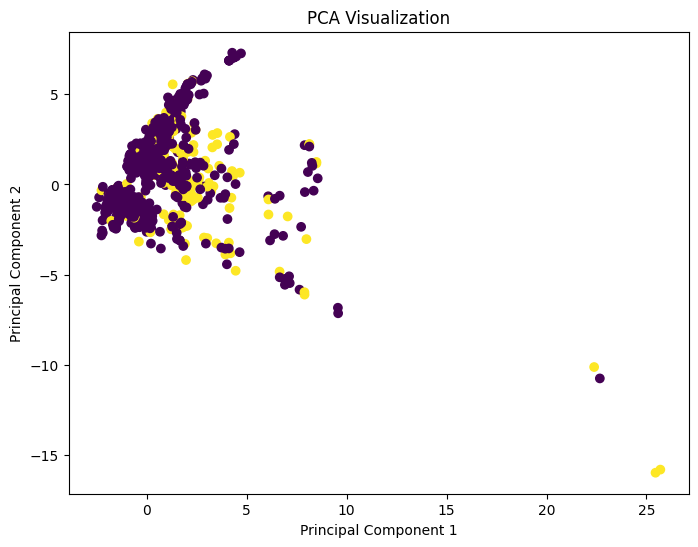

In [20]:
# PCA visualization:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis') # Color by survived
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.show()